<a href="https://colab.research.google.com/github/Mhamuda/CSEM2151-Computer_Vision/blob/main/Comparision_of_MLP_CNN_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install seaborn scikit-learn tqdm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import time
from tqdm import tqdm
import pandas as pd
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# Normalize MNIST


In [ ]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

#Download MNIST dataset

In [ ]:
mnist_train_full = datasets.MNIST(
    root = './data',
    train=True,
    download=True,
    transform=transform_mnist
    )

mnist_test = datasets.MNIST(
    root = './data',
    train=False,
    download=True,
    transform=transform_mnist
    )

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]


#Split MNIST into train and validation set

In [ ]:
mnist_train, mnist_val = random_split(
    mnist_train_full,
     [50000, 10000]
    )

#Create MNIST dataloader


In [ ]:
mnist_train_loader = DataLoader(
    mnist_train,
    batch_size=64,
    shuffle=True
    )

mnist_val_loader = DataLoader(
    mnist_val,
    batch_size=64,
    shuffle=False
    )

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=64,
    shuffle=False
    )

#Print MNIST dataset sizes

In [ ]:
print("MNIST dataset: ")
print("-----------------------")
print("Train: ", len(mnist_train))
print("Validation: ", len(mnist_val))
print("Test: ", len(mnist_test))
print("Total: ", len(mnist_train) + len(mnist_val) + len(mnist_test))

MNIST dataset: 
-----------------------
Train:  50000
Validation:  10000
Test:  10000
Total:  70000


#Normalize CIFAR-10

In [ ]:
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

In [ ]:
cifar_train_full = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_cifar
    )

cifar_test = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_cifar
    )

100%|██████████| 170M/170M [58:03<00:00, 48.9kB/s]


#Split CIFAR-10 into train and validation set

In [ ]:
cifar_train, cifar_val = random_split(
    cifar_train_full,
     [40000, 10000]
    )

#Create CIFAR-10 dataloader

In [ ]:
cifar_train_loader = DataLoader(
    cifar_train,
    batch_size=64,
    shuffle=True
    )

cifar_val_loader = DataLoader(
    cifar_val,
    batch_size=64,
    shuffle=False
    )

cifar_test_loader = DataLoader(
    cifar_test,
    batch_size=64,
    shuffle=False
    )

#Print CIFAR-10 dataset sizes

In [ ]:
print("CIFER-10 dataset: ")
print("-----------------------")
print("Train: ", len(cifar_train))
print("Validation: ", len(cifar_val))
print("Test: ", len(cifar_test))
print("Total: ", len(cifar_train) + len(cifar_val) + len(cifar_test))

CIFER-10 dataset: 
-----------------------
Train:  40000
Validation:  10000
Test:  10000
Total:  60000


#Define function for sample visualizarion

In [ ]:
def visualize_samples(loader, title="Samples", num=10):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, num, figsize=(15, 3))
    for i in range(num):
        img = images[i].permute(1,2,0) if images[i].shape[0] == 3 else images[i].squeeze()
        axes[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[i].set_title(f"Label: {labels[i]}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.show()

#Visualize some samples from MNIST dataset

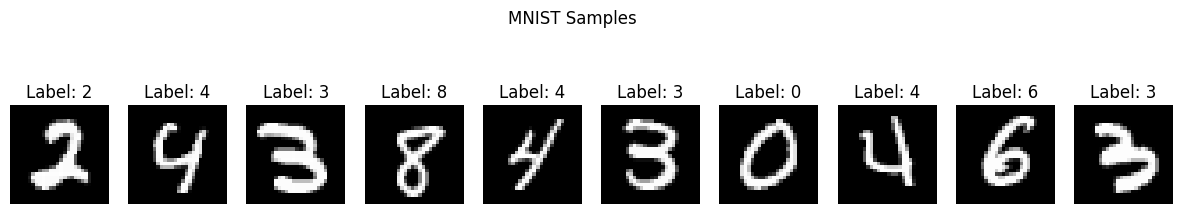

In [ ]:
visualize_samples(mnist_train_loader, "MNIST Samples")

#Visualize some samples from CIFAR-10 dataset

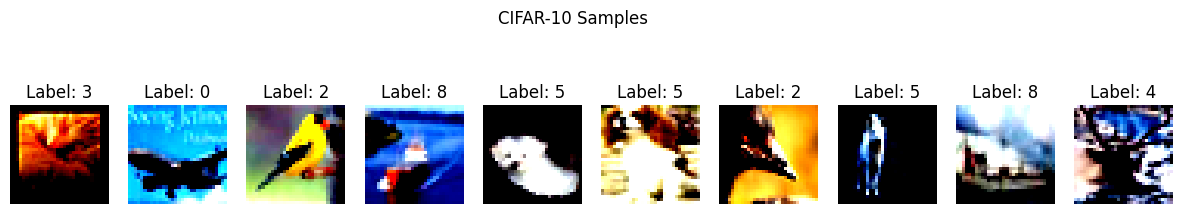

In [ ]:
visualize_samples(cifar_train_loader, "CIFAR-10 Samples")

#Build MLP model

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x): return self.net(x)

#Build CNN model

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7 if in_channels==1 else 64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

#Build Vision Transformer (ViT) model

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, in_channels,
                 patch_size, num_classes=10,
                 embed_dim=128, depth=4):

        super().__init__()

        self.n_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
            )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,
            batch_first=True,
            dropout=0.1
            )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
            )

        self.head = nn.Linear(
            embed_dim,
            num_classes
            )

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) + self.pos_embed
        x = self.transformer(x)
        return self.head(x[:, 0])

#Create training function

In [ ]:
def train_model(model, train_loader, val_loader, epochs, model_name="Model"):

    criterion = nn.CrossEntropyLoss()

    if isinstance(model, VisionTransformer):
        optimizer = optim.AdamW(
            model.parameters(),
            lr=3e-4,
            weight_decay=1e-4
        )
    else:
        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        print(
            f"{model_name} Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_losses[-1]:.4f} | "
            f"Val Loss: {val_losses[-1]:.4f}"
        )

    total_time = time.time() - start_time

    print(f"{model_name} Training Time: {total_time:.2f} seconds")

    return train_losses, val_losses, total_time

#Train MLP for MNIST

In [ ]:
mlp = MLP(28*28).to(device)

print("--------------Training MLP--------------\n")

mlp_train, mlp_val, mlp_time = train_model(
    mlp,
    mnist_train_loader,
    mnist_val_loader,
    epochs=20,
    model_name="MLP"
    )

--------------Training MLP--------------



100%|██████████| 782/782 [00:12<00:00, 63.34it/s]


MLP Epoch 1/20 | Train Loss: 0.2221 | Val Loss: 0.1225


100%|██████████| 782/782 [00:11<00:00, 65.59it/s]


MLP Epoch 2/20 | Train Loss: 0.0906 | Val Loss: 0.1015


...

MLP Epoch 18/20 | Train Loss: 0.0089 | Val Loss: 0.1774


100%|██████████| 782/782 [00:11<00:00, 65.94it/s]


MLP Epoch 19/20 | Train Loss: 0.0185 | Val Loss: 0.1401


100%|██████████| 782/782 [00:11<00:00, 66.87it/s]


MLP Epoch 20/20 | Train Loss: 0.0127 | Val Loss: 0.1445
MLP Training Time: 283.41 seconds


#Train CNN for MNIST

In [ ]:
cnn = CNN(in_channels=1).to(device)

print("--------------Training CNN--------------\n")

cnn_train, cnn_val, cnn_time = train_model(
    cnn,
    mnist_train_loader,
    mnist_val_loader,
    epochs=20,
    model_name="CNN"
    )

--------------Training CNN--------------



100%|██████████| 782/782 [00:13<00:00, 56.59it/s]


CNN Epoch 1/20 | Train Loss: 0.1512 | Val Loss: 0.0720


100%|██████████| 782/782 [00:13<00:00, 58.68it/s]


CNN Epoch 2/20 | Train Loss: 0.0444 | Val Loss: 0.0468


...

CNN Epoch 18/20 | Train Loss: 0.0050 | Val Loss: 0.0692


100%|██████████| 782/782 [00:14<00:00, 55.60it/s]


CNN Epoch 19/20 | Train Loss: 0.0033 | Val Loss: 0.0466


100%|██████████| 782/782 [00:12<00:00, 60.90it/s]


CNN Epoch 20/20 | Train Loss: 0.0007 | Val Loss: 0.0612
CNN Training Time: 344.67 seconds


#Train ViT for MNIST

In [ ]:
vit = VisionTransformer(img_size=28, in_channels=1, patch_size=4).to(device)

print("--------------Training ViT--------------")

vit_train, vit_val, vit_time = train_model(
    vit,
    mnist_train_loader,
    mnist_val_loader,
    epochs=30,
    model_name="ViT"
    )

--------------Training ViT--------------


100%|██████████| 782/782 [00:32<00:00, 23.99it/s]


ViT Epoch 1/30 | Train Loss: 0.5242 | Val Loss: 0.1755


100%|██████████| 782/782 [00:34<00:00, 22.74it/s]


ViT Epoch 2/30 | Train Loss: 0.1715 | Val Loss: 0.1527


...

ViT Epoch 28/30 | Train Loss: 0.0260 | Val Loss: 0.0806


100%|██████████| 782/782 [00:28<00:00, 27.43it/s]


ViT Epoch 29/30 | Train Loss: 0.0229 | Val Loss: 0.0788


100%|██████████| 782/782 [00:28<00:00, 27.83it/s]


ViT Epoch 30/30 | Train Loss: 0.0228 | Val Loss: 0.0710
ViT Training Time: 996.38 seconds


#Define evaluation function

In [ ]:
@torch.no_grad()

def full_evaluate(model, test_loader, model_name):
    model.eval()
    preds, trues = [], []
    start = time.time()

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds.extend(outputs.argmax(dim=1).cpu().numpy())
        trues.extend(labels.numpy())

    inf_time = (time.time() - start) / len(test_loader)
    acc = accuracy_score(trues, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(trues, preds, average='macro')

    print(f"\n=== {model_name} Results ===")
    print(f"Accuracy: {acc*100:.2f}% \n Precision: {prec:.4f} \n Recall: {rec:.4f} \n F1: {f1:.4f}")
    print(f"Training Time: {eval(f'{model_name.lower()}_time'):.1f}s \n Inference Time/batch: {inf_time:.4f}s")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Confusion Matrix
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return trues, preds

#Evaluate MLP for MNIST


=== MLP Results ===
Accuracy: 98.03% 
 Precision: 0.9805 
 Recall: 0.9800 
 F1: 0.9802
Training Time: 283.4s 
 Inference Time/batch: 0.0159s
Parameters: 535,818


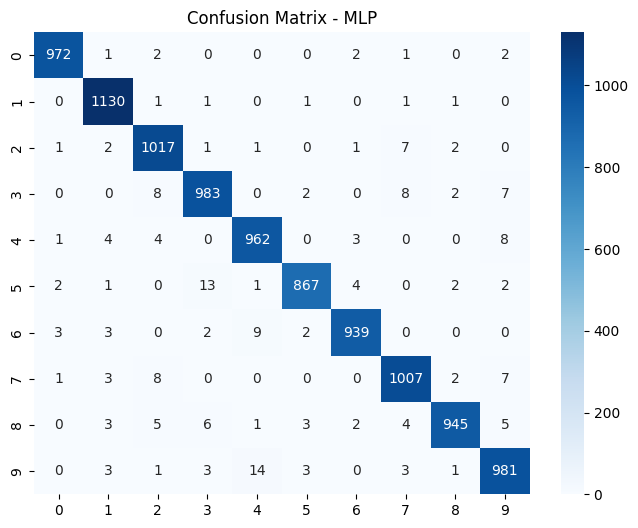

In [ ]:
mlp_true, mlp_pred = full_evaluate(
    mlp,
    mnist_test_loader,
    "MLP"
    )

#Evaluate CNN for MNIST


=== CNN Results ===
Accuracy: 99.14% 
 Precision: 0.9914 
 Recall: 0.9912 
 F1: 0.9913
Training Time: 344.7s 
 Inference Time/batch: 0.0129s
Parameters: 421,642


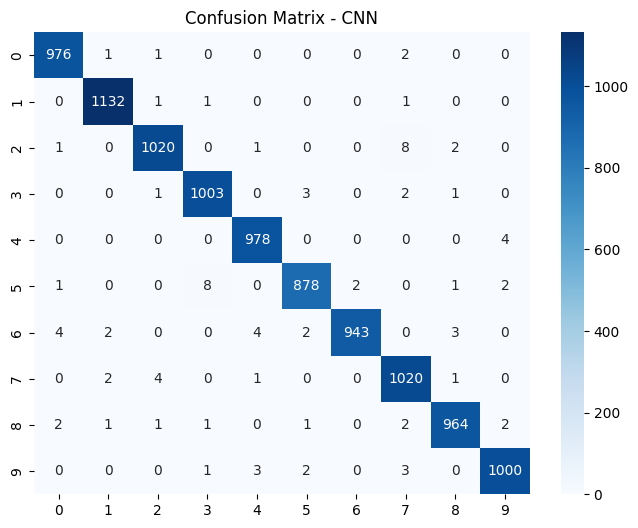

In [ ]:
cnn_true, cnn_pred = full_evaluate(
    cnn,
    mnist_test_loader,
    "CNN"
    )

#Evaluate ViT for MNIST


=== ViT Results ===
Accuracy: 98.43% 
 Precision: 0.9843 
 Recall: 0.9843 
 F1: 0.9843
Training Time: 996.4s 
 Inference Time/batch: 0.0207s
Parameters: 2,382,090


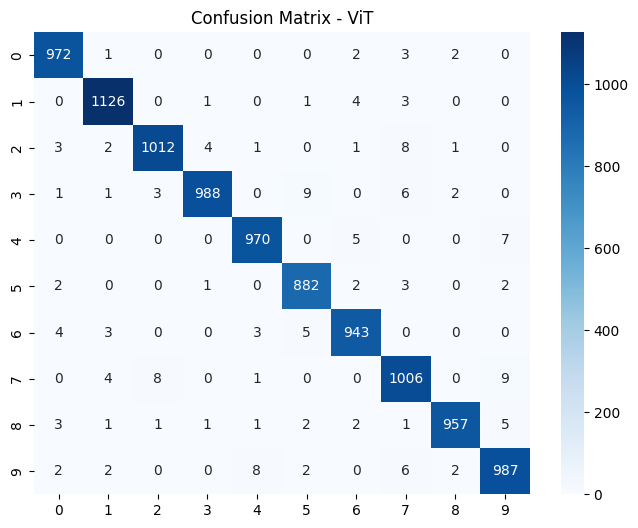

In [ ]:
vit_true, vit_pred = full_evaluate(
    vit,
    mnist_test_loader,
    "ViT"
    )

#Define function for plotting learning curves

In [ ]:
def plot_comparison(curve1, curve2, curve3,
                    label1, label2, label3,
                    title, ylabel):

    plt.figure(figsize=(8,5))

    plt.plot(curve1, marker='o', label=label1)
    plt.plot(curve2, marker='x', label=label2)
    plt.plot(curve3, marker='^', label=label3)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.legend()
    plt.grid(True)

    plt.show()

#Plot learning curve (Training loss) for MNIST

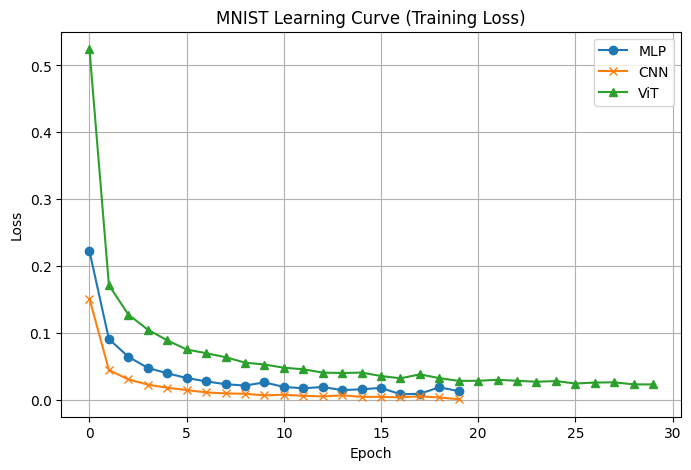

In [ ]:
plot_comparison(
    mlp_train,
    cnn_train,
    vit_train,
    "MLP",
    "CNN",
    "ViT",
    "MNIST Learning Curve (Training Loss)",
    "Loss"
)

#Plot learning curve (Validation loss) for MNIST

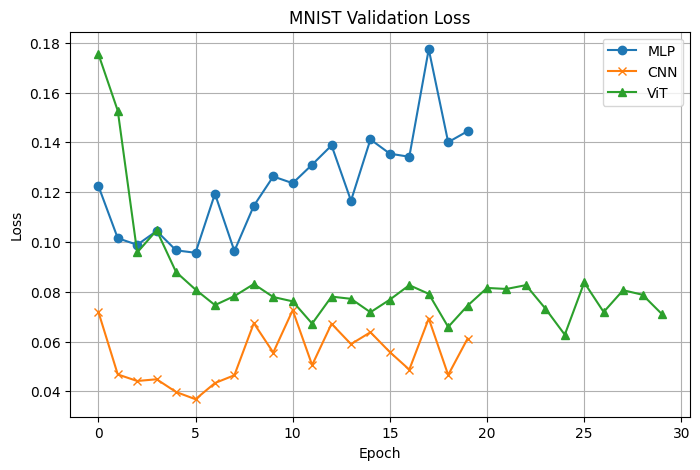

In [ ]:
plot_comparison(
    mlp_val,
    cnn_val,
    vit_val,
    "MLP",
    "CNN",
    "ViT",
    "MNIST Validation Loss",
    "Loss"
)

#Define function for correct or incorrect classified image for MNIST (grayscale)

In [ ]:
def show_correct_incorrect(model, loader, model_name, num_correct=5, num_incorrect=5):
    model.eval()

    correct_images, correct_pred, correct_true = [], [], []
    incorrect_images, incorrect_pred, incorrect_true = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            preds = outputs.argmax(dim=1)

            # Correct predictions
            correct_mask = (preds == labels.to(device))
            for i in range(len(correct_mask)):
                if correct_mask[i] and len(correct_images) < num_correct:
                    correct_images.append(images[i].cpu())
                    correct_pred.append(preds[i].item())
                    correct_true.append(labels[i].item())

            # Incorrect predictions
            incorrect_mask = (preds != labels.to(device))
            for i in range(len(incorrect_mask)):
                if incorrect_mask[i] and len(incorrect_images) < num_incorrect:
                    incorrect_images.append(images[i].cpu())
                    incorrect_pred.append(preds[i].item())
                    incorrect_true.append(labels[i].item())

            if len(correct_images) >= num_correct and len(incorrect_images) >= num_incorrect:
                break

    # ---------------- Correct Images ----------------
    if correct_images:
        fig, axes = plt.subplots(1, len(correct_images), figsize=(15, 4))

        if len(correct_images) == 1:
            axes = [axes]

        for i, ax in enumerate(axes):
            img = correct_images[i].squeeze()
            ax.imshow(img, cmap='gray')
            ax.set_title(
                f"Pred: {correct_pred[i]}\nTrue: {correct_true[i]}",
                fontsize=10
            )
            ax.axis('off')

        fig.suptitle(
            f"{model_name} - Correctly Classified Images",
            fontsize=16,
            fontweight='bold'
        )

        plt.tight_layout(rect=[0, 0, 1, 0.88])
        plt.show()

    # ---------------- Incorrect Images ----------------
    if incorrect_images:
        fig, axes = plt.subplots(1, len(incorrect_images), figsize=(15, 4))

        if len(incorrect_images) == 1:
            axes = [axes]

        for i, ax in enumerate(axes):
            img = incorrect_images[i].squeeze()
            ax.imshow(img, cmap='gray')
            ax.set_title(
                f"Pred: {incorrect_pred[i]}\nTrue: {incorrect_true[i]}",
                fontsize=10
            )
            ax.axis('off')

        fig.suptitle(
            f"{model_name} - Incorrectly Classified Images",
            fontsize=16,
            fontweight='bold'
        )

        plt.tight_layout(rect=[0, 0, 1, 0.88])
        plt.show()

# Show correct and incorrect images for MLP MNIST

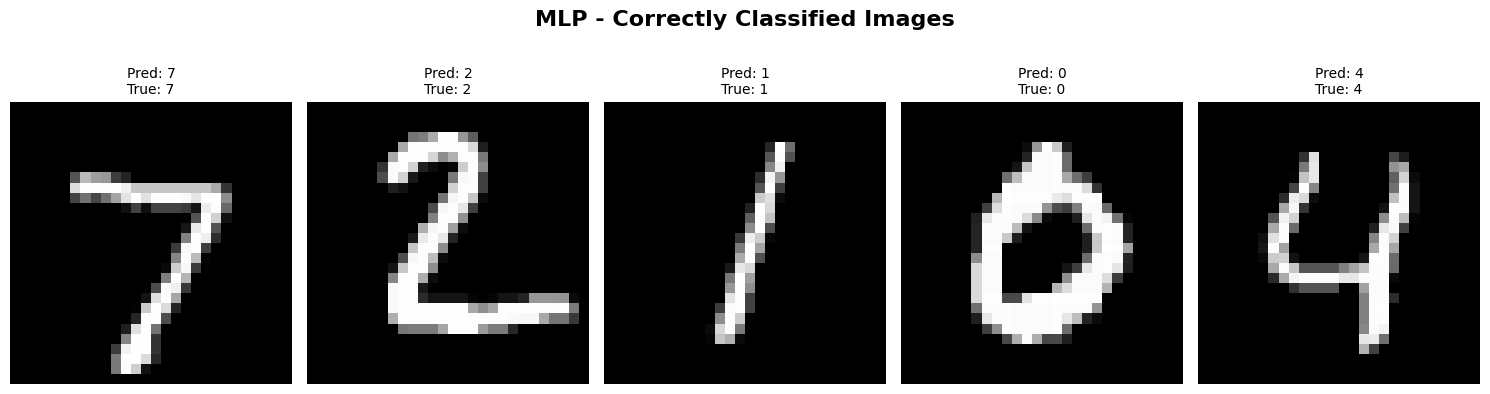

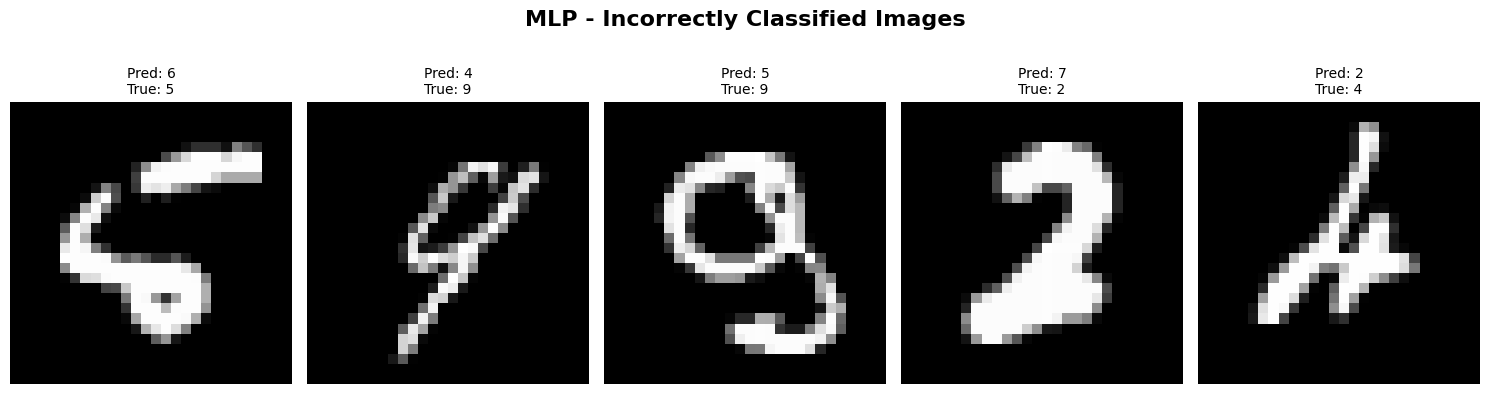

In [ ]:
show_correct_incorrect(
    mlp,
    mnist_test_loader,
    "MLP",
    num_correct=5,
    num_incorrect=5
    )

# Show correct and incorrect images for CNN MNIST

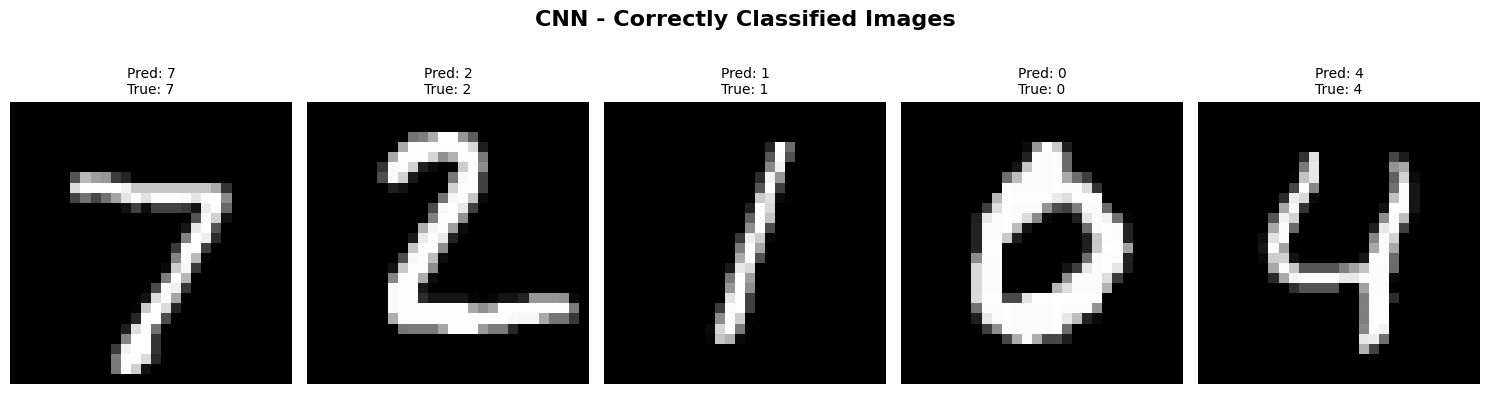

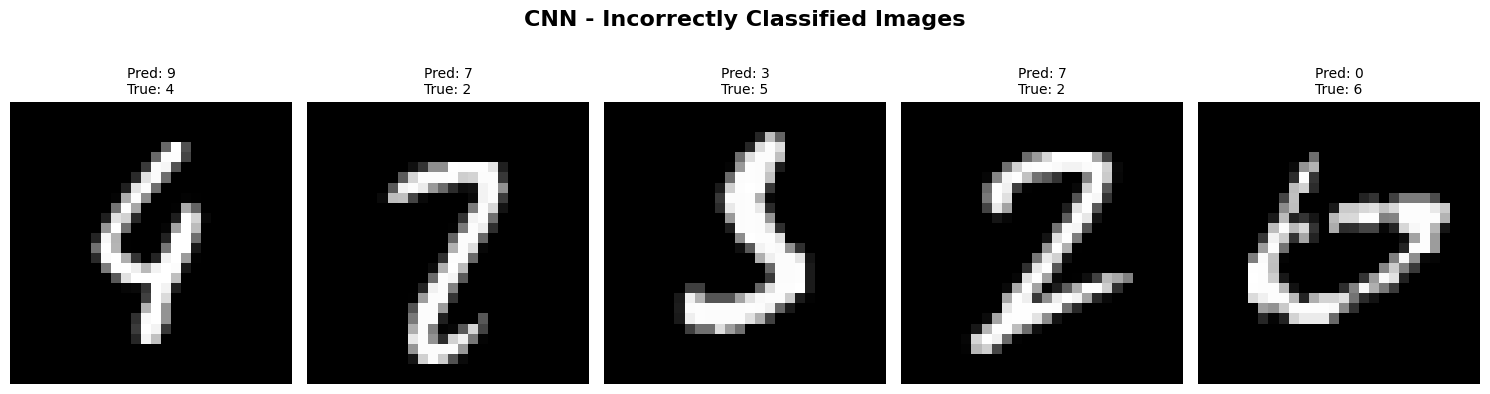

In [ ]:
show_correct_incorrect(
    cnn,
    mnist_test_loader,
    "CNN",
    num_correct=5,
    num_incorrect=5
    )

# Show correct and incorrect images for ViT MNIST

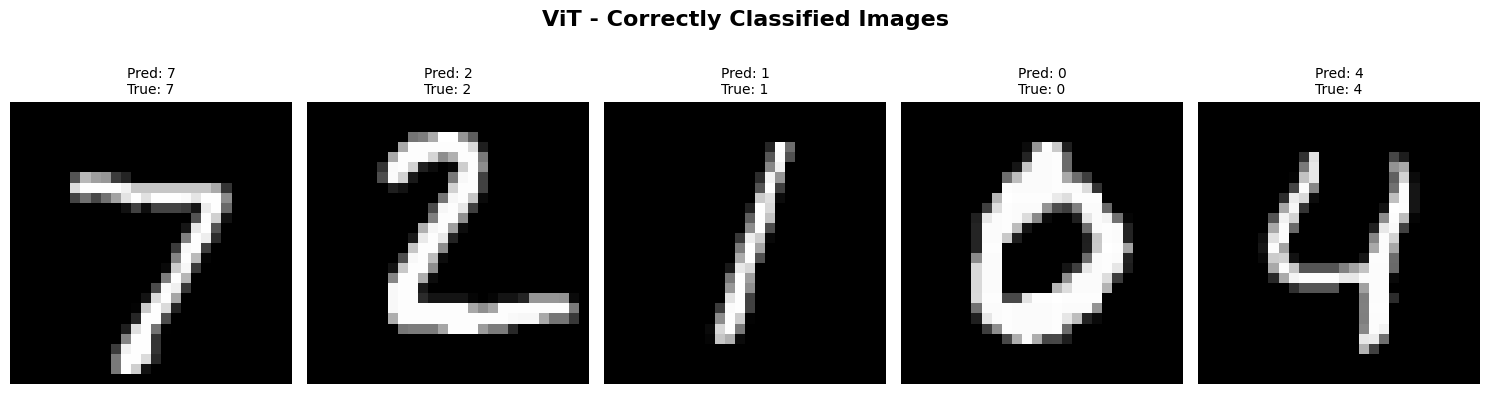

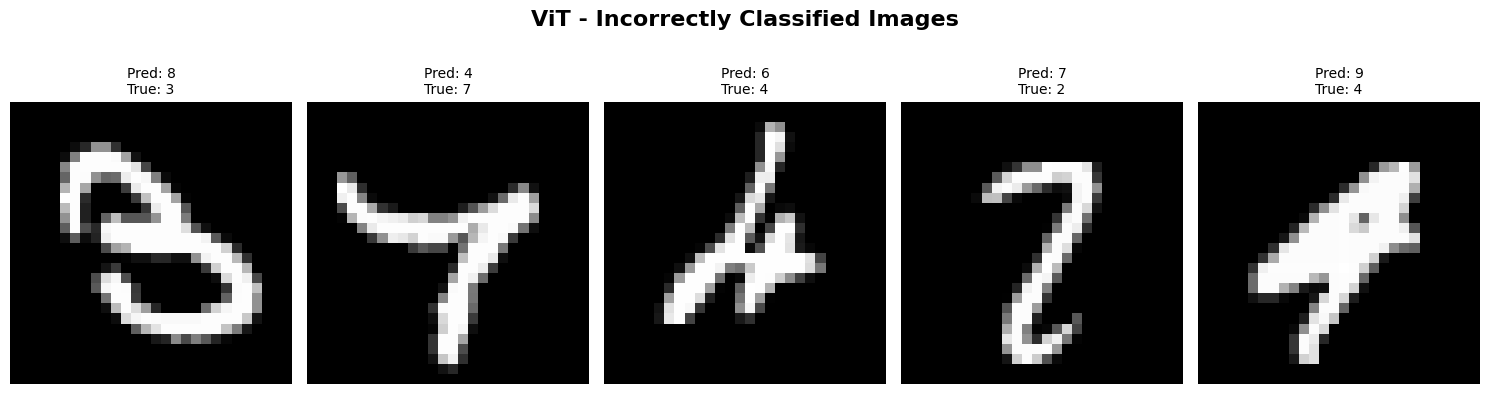

In [ ]:
show_correct_incorrect(
    vit,
    mnist_test_loader,
    "ViT",
    num_correct=5,
    num_incorrect=5
    )

#Show comparision table for MLP, CNN and ViT for MNISt dataset

In [ ]:
from IPython.display import display

# Create comparison table
data = {
    "Model": ["MLP", "CNN", "ViT"],

    "Parameters": [
        sum(p.numel() for p in mlp.parameters()),
        sum(p.numel() for p in cnn.parameters()),
        sum(p.numel() for p in vit.parameters())
    ],

    "Model Size (MB)": [
        sum(p.numel() for p in mlp.parameters()) * 4 / (1024 ** 2),
        sum(p.numel() for p in cnn.parameters()) * 4 / (1024 ** 2),
        sum(p.numel() for p in vit.parameters()) * 4 / (1024 ** 2)
    ],

    "Training Time (s)": [
        mlp_time,
        cnn_time,
        vit_time
    ],

    "Test Accuracy (%)": [
        accuracy_score(mlp_true, mlp_pred) * 100,
        accuracy_score(cnn_true, cnn_pred) * 100,
        accuracy_score(vit_true, vit_pred) * 100
    ]
}

df = pd.DataFrame(data)

# Format the columns
df["Parameters"] = df["Parameters"].map("{:,}".format)
df["Model Size (MB)"] = df["Model Size (MB)"].map("{:.2f}".format)
df["Training Time (s)"] = df["Training Time (s)"].map("{:.2f}".format)
df["Test Accuracy (%)"] = df["Test Accuracy (%)"].map("{:.2f}".format)

# Display styled table
display(
    df.style
      .hide(axis="index")
      .set_caption("MNIST Performance Comparison")
      .set_properties(**{
          "text-align": "center",
          "border": "1px solid black"
      })
      .set_table_styles([
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("font-size", "16px"),
                  ("font-weight", "bold"),
                  ("text-align", "center"),
                  ("padding", "10px")
              ]
          },
          {
              "selector": "th",
              "props": [
                  ("background-color", "#4F81BD"),
                  ("color", "white"),
                  ("font-weight", "bold"),
                  ("text-align", "center"),
                  ("border", "1px solid black"),
                  ("padding", "8px")
              ]
          },
          {
              "selector": "td",
              "props": [
                  ("text-align", "center"),
                  ("border", "1px solid black"),
                  ("padding", "8px")
              ]
          }
      ])
)

Model,Parameters,Model Size (MB),Training Time (s),Test Accuracy (%)
MLP,"535,818",2.04,283.41,98.03
CNN,"421,642",1.61,344.67,99.14
ViT,"2,382,090",9.09,996.38,98.43


#Save models

In [ ]:
torch.save(mlp.state_dict(), '/content/mlp_mnist.pth')
torch.save(cnn.state_dict(), '/content/cnn_mnist.pth')
torch.save(vit.state_dict(), '/content/vit_mnist.pth')

#Train MLP for CIFAR-10


In [ ]:
mlp_cifar = MLP(3*32*32).to(device)

print("------------------Training MLP------------------\n")

mlp_train_c, mlp_val_c, mlp_time_c = train_model(
    mlp_cifar,
    cifar_train_loader,
    cifar_val_loader,
    epochs=20,
    model_name="MLP_CIFAR"
    )


------------------Training MLP------------------



100%|██████████| 625/625 [00:11<00:00, 56.75it/s]


MLP_CIFAR Epoch 1/20 | Train Loss: 1.6815 | Val Loss: 1.5642


100%|██████████| 625/625 [00:13<00:00, 46.99it/s]


MLP_CIFAR Epoch 2/20 | Train Loss: 1.4834 | Val Loss: 1.4838


...

MLP_CIFAR Epoch 18/20 | Train Loss: 0.5401 | Val Loss: 2.0856


100%|██████████| 625/625 [00:10<00:00, 59.26it/s]


MLP_CIFAR Epoch 19/20 | Train Loss: 0.5080 | Val Loss: 2.2014


100%|██████████| 625/625 [00:10<00:00, 60.69it/s]


MLP_CIFAR Epoch 20/20 | Train Loss: 0.4966 | Val Loss: 2.3139
MLP_CIFAR Training Time: 268.17 seconds


#Train CNN for CIFAR-10

In [ ]:
cnn_cifar = CNN(in_channels=3).to(device)

print("------------------Training CNN------------------\n")

cnn_train_c, cnn_val_c, cnn_time_c = train_model(
    cnn_cifar,
    cifar_train_loader,
    cifar_val_loader,
    epochs=20,
    model_name="CNN_CIFAR"
    )


------------------Training CNN------------------



100%|██████████| 625/625 [00:11<00:00, 53.59it/s]


CNN_CIFAR Epoch 1/20 | Train Loss: 1.3817 | Val Loss: 1.0905


100%|██████████| 625/625 [00:11<00:00, 53.87it/s]


CNN_CIFAR Epoch 2/20 | Train Loss: 0.9975 | Val Loss: 0.9849


...

CNN_CIFAR Epoch 18/20 | Train Loss: 0.0874 | Val Loss: 1.9671


100%|██████████| 625/625 [00:11<00:00, 53.86it/s]


CNN_CIFAR Epoch 19/20 | Train Loss: 0.0646 | Val Loss: 2.1137


100%|██████████| 625/625 [00:11<00:00, 53.68it/s]


CNN_CIFAR Epoch 20/20 | Train Loss: 0.0584 | Val Loss: 2.2539
CNN_CIFAR Training Time: 281.51 seconds


#Train ViT for CIFAR-10

In [ ]:
vit_cifar = VisionTransformer(img_size=32, in_channels=3, patch_size=4).to(device)

print("------------------Training ViT------------------\n")

vit_train_c, vit_val_c, vit_time_c = train_model(
    vit_cifar,
    cifar_train_loader,
    cifar_val_loader,
    epochs=30,
    model_name="ViT_CIFAR"
    )


------------------Training ViT------------------



100%|██████████| 625/625 [00:30<00:00, 20.74it/s]


ViT_CIFAR Epoch 1/30 | Train Loss: 1.7655 | Val Loss: 1.4592


100%|██████████| 625/625 [00:30<00:00, 20.56it/s]


ViT_CIFAR Epoch 2/30 | Train Loss: 1.4210 | Val Loss: 1.3077


...

ViT_CIFAR Epoch 28/30 | Train Loss: 0.2905 | Val Loss: 1.3925


100%|██████████| 625/625 [00:30<00:00, 20.24it/s]


ViT_CIFAR Epoch 29/30 | Train Loss: 0.2699 | Val Loss: 1.3589


100%|██████████| 625/625 [00:30<00:00, 20.33it/s]


ViT_CIFAR Epoch 30/30 | Train Loss: 0.2686 | Val Loss: 1.4032
ViT_CIFAR Training Time: 1056.11 seconds


In [ ]:
mlp_cifar_time = mlp_time_c
cnn_cifar_time = cnn_time_c
vit_cifar_time = vit_time_c

#Evaluate MLP for CIFAR-10



=== MLP_CIFAR Results ===
Accuracy: 50.68% 
 Precision: 0.5116 
 Recall: 0.5068 
 F1: 0.5069
Training Time: 268.2s 
 Inference Time/batch: 0.0145s
Parameters: 1,707,274


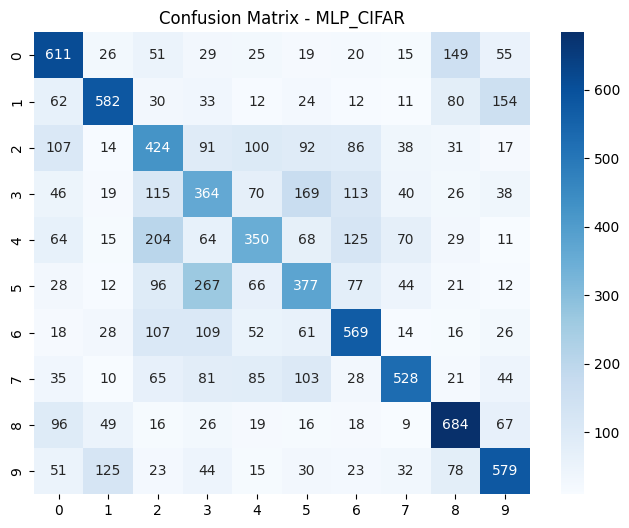

In [ ]:
mlp_true_c, mlp_pred_c = full_evaluate(
    mlp_cifar,
    cifar_test_loader,
    "MLP_CIFAR"
    )

#Evaluate CNN for CIFAR-10


=== CNN_CIFAR Results ===
Accuracy: 69.42% 
 Precision: 0.6982 
 Recall: 0.6942 
 F1: 0.6939
Training Time: 281.5s 
 Inference Time/batch: 0.0190s
Parameters: 545,098


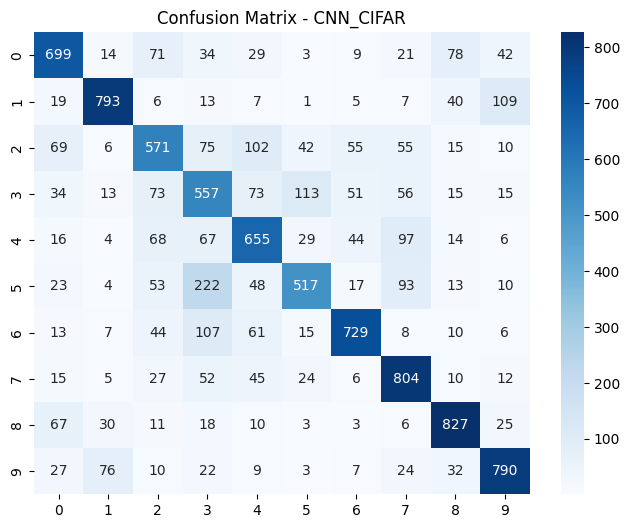

In [ ]:
cnn_true_c, cnn_pred_c = full_evaluate(
    cnn_cifar,
    cifar_test_loader,
    "CNN_CIFAR"
    )

#Evaluate ViT for CIFAR-10


=== ViT_CIFAR Results ===
Accuracy: 66.39% 
 Precision: 0.6632 
 Recall: 0.6639 
 F1: 0.6610
Training Time: 1056.1s 
 Inference Time/batch: 0.0238s
Parameters: 2,388,106


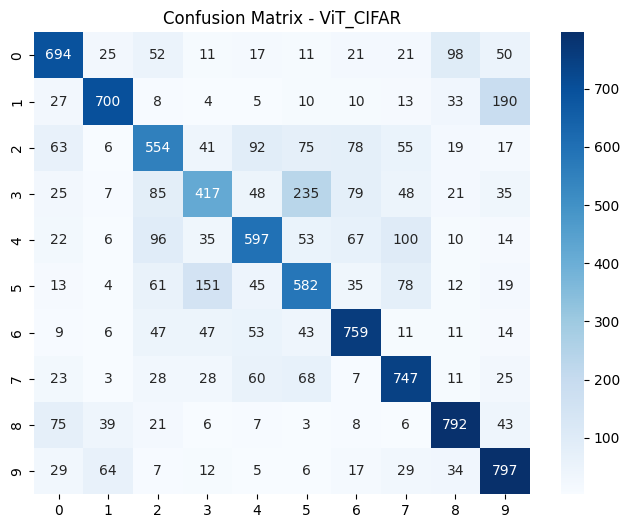

In [ ]:
vit_true_c, vit_pred_c = full_evaluate(
    vit_cifar,
    cifar_test_loader,
    "ViT_CIFAR"
    )

#Plot learning curve (Training loss) for CIFAR-10

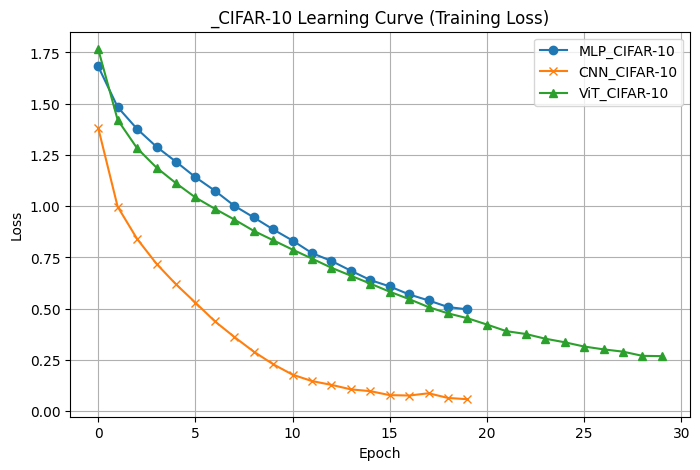

In [ ]:
plot_comparison(
    mlp_train_c,
    cnn_train_c,
    vit_train_c,
    "MLP_CIFAR-10",
    "CNN_CIFAR-10",
    "ViT_CIFAR-10",
    "_CIFAR-10 Learning Curve (Training Loss)",
    "Loss"
)

#Plot learning curve (Validation loss) for  CIFAR-10


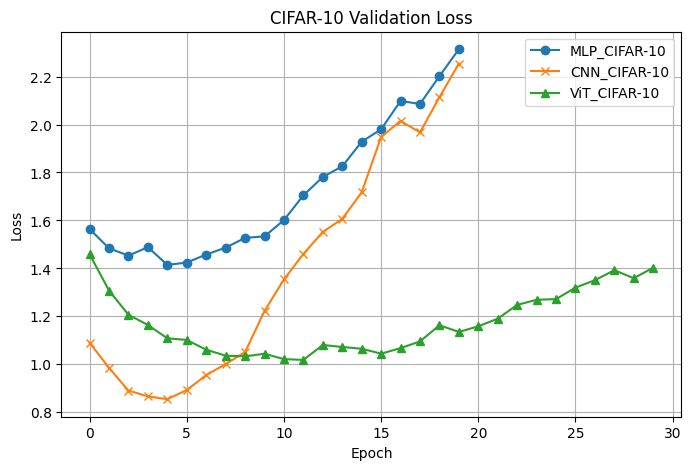

In [ ]:
plot_comparison(
    mlp_val_c,
    cnn_val_c,
    vit_val_c,
    "MLP_CIFAR-10",
    "CNN_CIFAR-10",
    "ViT_CIFAR-10",
    "CIFAR-10 Validation Loss",
    "Loss"
)

#Define function for correct or incorrect classified image for CIFAR-10 (RGB)

In [ ]:
cifar_classes = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

def show_correct_incorrect_cifar(model, loader, model_name, num_correct=5, num_incorrect=5):
    model.eval()

    correct_images, correct_pred, correct_true = [], [], []
    incorrect_images, incorrect_pred, incorrect_true = [], [], []

    # Mean and Std used for CIFAR-10 normalization
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    with torch.no_grad():
        for images, labels in loader:

            images_dev = images.to(device)
            outputs = model(images_dev)
            preds = outputs.argmax(dim=1)

            for i in range(len(labels)):

                if preds[i] == labels[i] and len(correct_images) < num_correct:
                    correct_images.append(images[i].cpu())
                    correct_pred.append(preds[i].item())
                    correct_true.append(labels[i].item())

                elif preds[i] != labels[i] and len(incorrect_images) < num_incorrect:
                    incorrect_images.append(images[i].cpu())
                    incorrect_pred.append(preds[i].item())
                    incorrect_true.append(labels[i].item())

            if len(correct_images) >= num_correct and len(incorrect_images) >= num_incorrect:
                break

    # ---------------- Correct Images ----------------
    if correct_images:

        fig, axes = plt.subplots(1, len(correct_images), figsize=(15,4))

        if len(correct_images) == 1:
            axes = [axes]

        for i, ax in enumerate(axes):

            img = correct_images[i].permute(1, 2, 0).numpy()

            # Unnormalize image
            img = img * std + mean
            img = np.clip(img, 0, 1)

            ax.imshow(img)

            ax.set_title(
                f"Pred: {cifar_classes[correct_pred[i]]}\nTrue: {cifar_classes[correct_true[i]]}",
                fontsize=10
            )

            ax.axis("off")

        fig.suptitle(
            f"{model_name} - Correctly Classified Images",
            fontsize=16,
            fontweight="bold"
        )

        plt.tight_layout(rect=[0,0,1,0.90])
        plt.show()

    # ---------------- Incorrect Images ----------------
    if incorrect_images:

        fig, axes = plt.subplots(1, len(incorrect_images), figsize=(15,4))

        if len(incorrect_images) == 1:
            axes = [axes]

        for i, ax in enumerate(axes):

            img = incorrect_images[i].permute(1, 2, 0).numpy()

            # Unnormalize image
            img = img * std + mean
            img = np.clip(img, 0, 1)

            ax.imshow(img)

            ax.set_title(
                f"Pred: {cifar_classes[incorrect_pred[i]]}\nTrue: {cifar_classes[incorrect_true[i]]}",
                fontsize=10
            )

            ax.axis("off")

        fig.suptitle(
            f"{model_name} - Incorrectly Classified Images",
            fontsize=16,
            fontweight="bold"
        )

        plt.tight_layout(rect=[0,0,1,0.90])
        plt.show()

# Show correct and incorrect images for MLP CIFAR-10


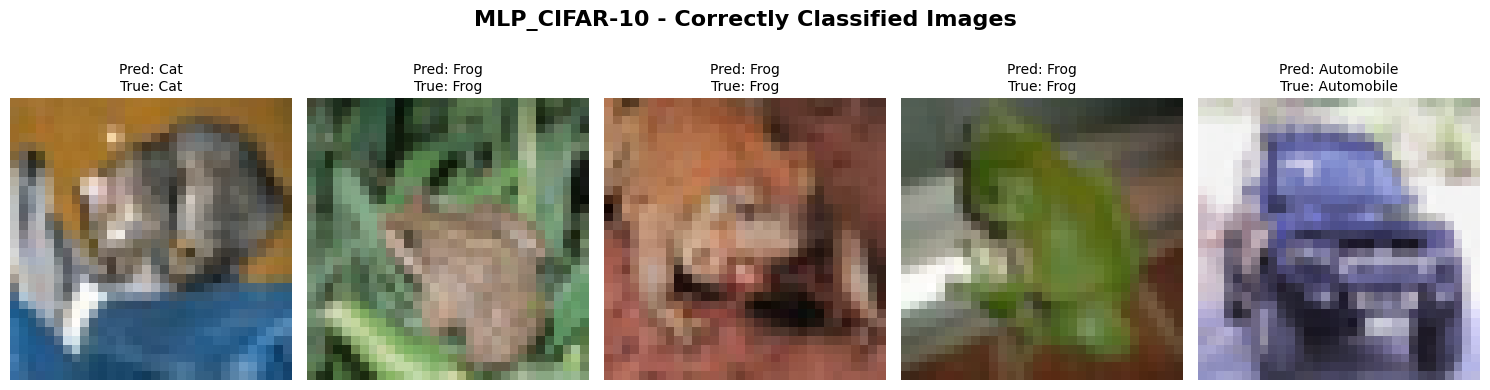

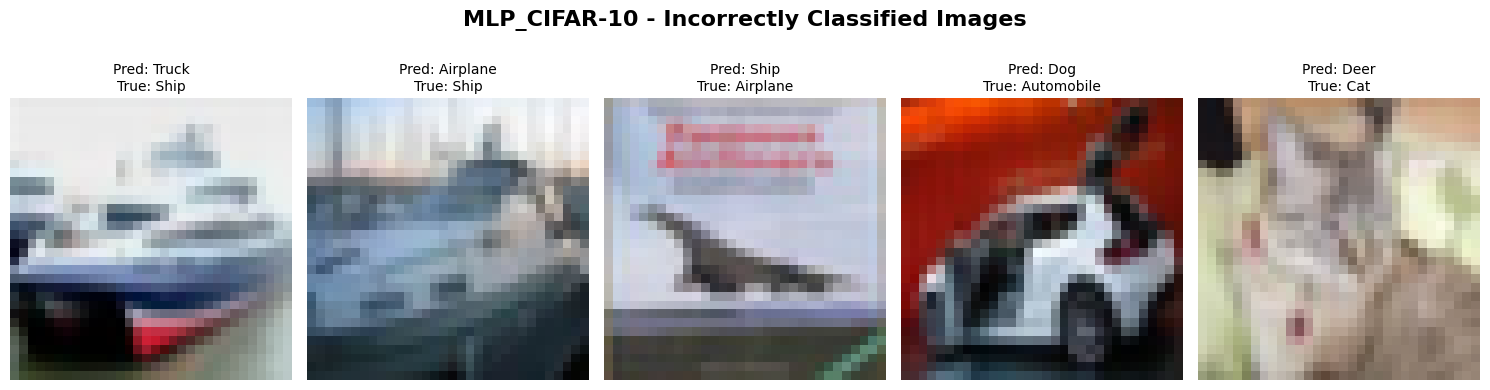

In [ ]:
show_correct_incorrect_cifar(
    mlp_cifar,
    cifar_test_loader,
    "MLP_CIFAR-10",
    num_correct=5,
    num_incorrect=5
    )

# Show correct and incorrect images for CNN CIFAR-10


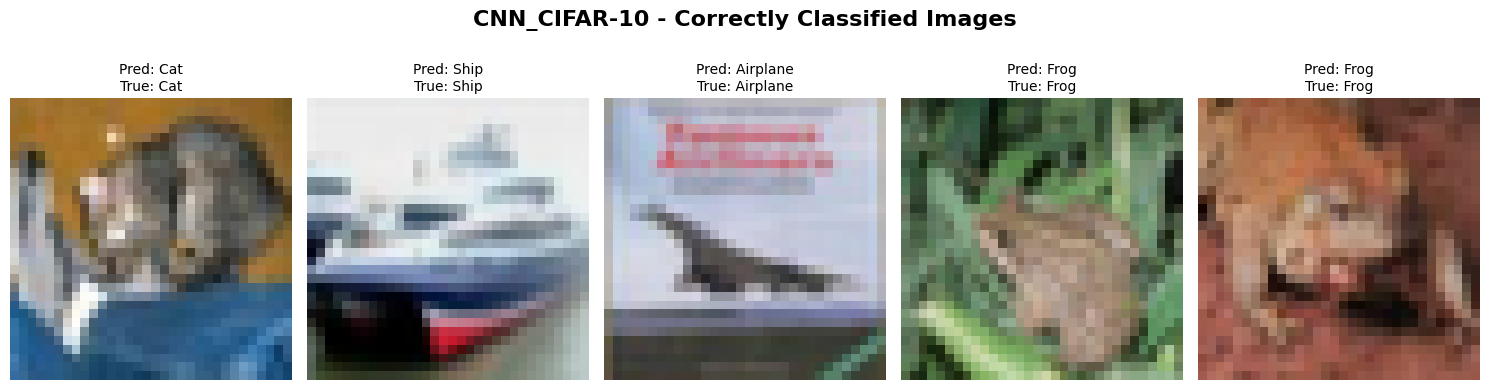

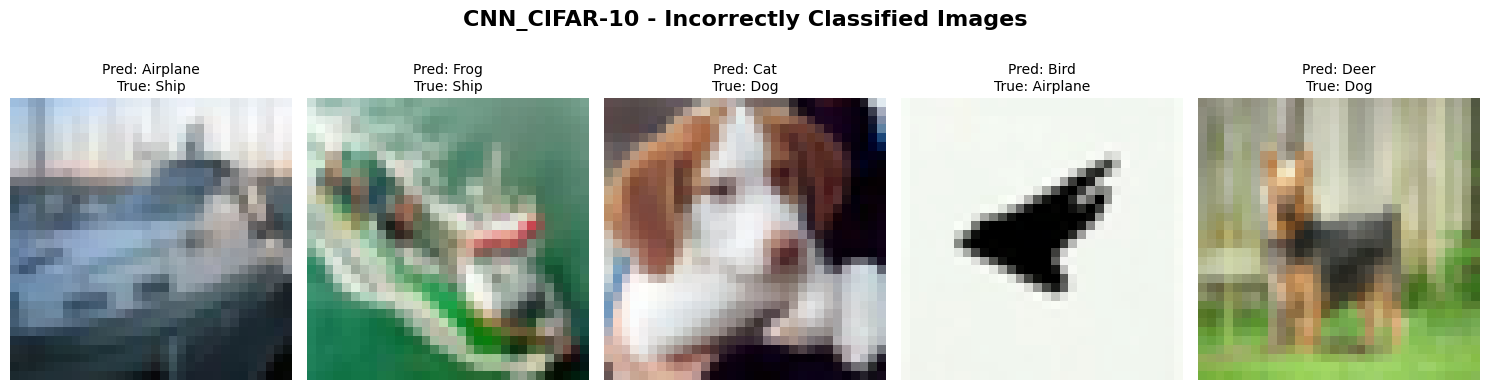

In [ ]:
show_correct_incorrect_cifar(
    cnn_cifar,
    cifar_test_loader,
    "CNN_CIFAR-10",
    num_correct=5,
    num_incorrect=5
    )

# Show correct and incorrect images for ViT CIFAR-10


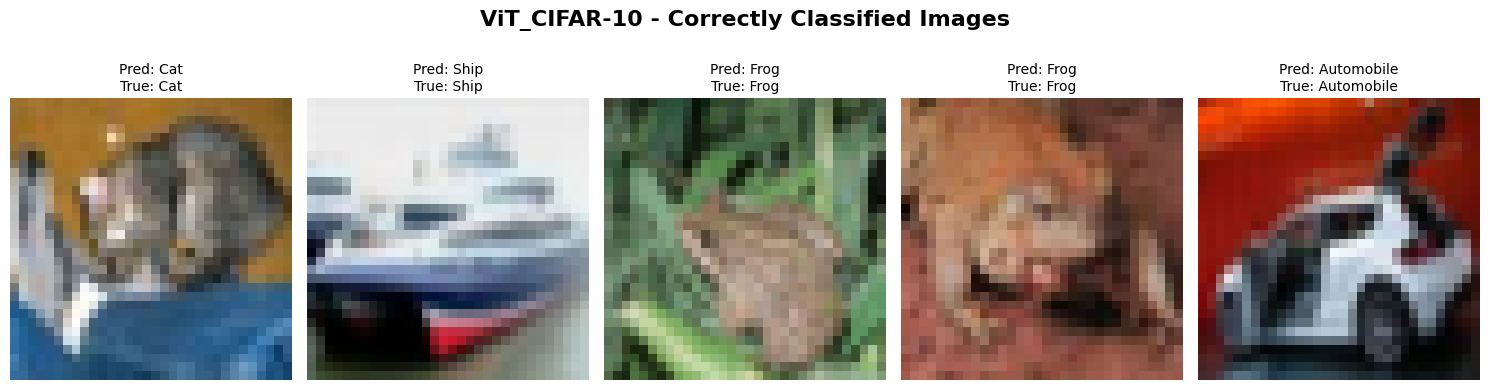

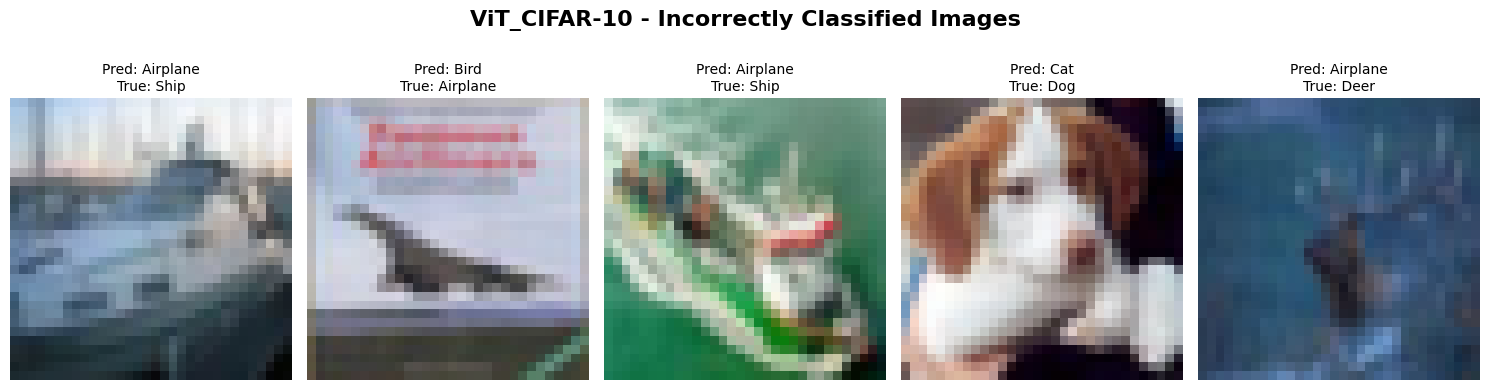

In [ ]:
show_correct_incorrect_cifar(
    vit_cifar,
    cifar_test_loader,
    "ViT_CIFAR-10",
    num_correct=5,
    num_incorrect=5
    )

#Show comparision table for MLP, CNN and ViT for CIFAR-10 dataset

In [ ]:
data = {
    "Model": ["MLP", "CNN", "ViT"],

    "Parameters": [
        sum(p.numel() for p in mlp_cifar.parameters()),
        sum(p.numel() for p in cnn_cifar.parameters()),
        sum(p.numel() for p in vit_cifar.parameters())
    ],

    "Model Size (MB)": [
        sum(p.numel() for p in mlp_cifar.parameters()) * 4 / (1024 ** 2),
        sum(p.numel() for p in cnn_cifar.parameters()) * 4 / (1024 ** 2),
        sum(p.numel() for p in vit_cifar.parameters()) * 4 / (1024 ** 2)
    ],

    "Training Time (s)": [
        mlp_time_c,
        cnn_time_c,
        vit_time_c
    ],

    "Test Accuracy (%)": [
        accuracy_score(mlp_true_c, mlp_pred_c) * 100,
        accuracy_score(cnn_true_c, cnn_pred_c) * 100,
        accuracy_score(vit_true_c, vit_pred_c) * 100
    ]
}

df = pd.DataFrame(data)

# Format the columns
df["Parameters"] = df["Parameters"].map("{:,}".format)
df["Model Size (MB)"] = df["Model Size (MB)"].map("{:.2f}".format)
df["Training Time (s)"] = df["Training Time (s)"].map("{:.2f}".format)
df["Test Accuracy (%)"] = df["Test Accuracy (%)"].map("{:.2f}".format)

# Display styled table
display(
    df.style
      .hide(axis="index")
      .set_caption("CIFAR-10 Performance Comparison")
      .set_properties(**{
          "text-align": "center",
          "border": "1px solid black"
      })
      .set_table_styles([
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("font-size", "16px"),
                  ("font-weight", "bold"),
                  ("text-align", "center"),
                  ("padding", "10px")
              ]
          },
          {
              "selector": "th",
              "props": [
                  ("background-color", "#4F81BD"),
                  ("color", "white"),
                  ("font-weight", "bold"),
                  ("text-align", "center"),
                  ("border", "1px solid black"),
                  ("padding", "8px")
              ]
          },
          {
              "selector": "td",
              "props": [
                  ("text-align", "center"),
                  ("border", "1px solid black"),
                  ("padding", "8px")
              ]
          }
      ])
)

Model,Parameters,Model Size (MB),Training Time (s),Test Accuracy (%)
MLP,"1,707,274",6.51,268.17,50.68
CNN,"545,098",2.08,281.51,69.42
ViT,"2,388,106",9.11,1056.11,66.39


#Final accuracy comparision on both MNIST and CIFAR-10 datasets

In [ ]:
mnist_mlp_acc = accuracy_score(mlp_true, mlp_pred) * 100
mnist_cnn_acc = accuracy_score(cnn_true, cnn_pred) * 100
mnist_vit_acc = accuracy_score(vit_true, vit_pred) * 100

cifar_mlp_acc = accuracy_score(mlp_true_c, mlp_pred_c) * 100
cifar_cnn_acc = accuracy_score(cnn_true_c, cnn_pred_c) * 100
cifar_vit_acc = accuracy_score(vit_true_c, vit_pred_c) * 100

comparison_df = pd.DataFrame({
    "Dataset": ["MNIST", "CIFAR-10"],
    "MLP (%)": [mnist_mlp_acc, cifar_mlp_acc],
    "CNN (%)": [mnist_cnn_acc, cifar_cnn_acc],
    "ViT (%)": [mnist_vit_acc, cifar_vit_acc]
})

comparison_df["MLP (%)"] = comparison_df["MLP (%)"].map("{:.2f}".format)
comparison_df["CNN (%)"] = comparison_df["CNN (%)"].map("{:.2f}".format)
comparison_df["ViT (%)"] = comparison_df["ViT (%)"].map("{:.2f}".format)

display(
    comparison_df.style
        .hide(axis="index")
        .set_caption("Final Accuracy Comparison")
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid black"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#4F81BD"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("border", "1px solid black")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("border", "1px solid black")
                ]
            }
        ])
)

Dataset,MLP (%),CNN (%),ViT (%)
MNIST,98.03,99.14,98.43
CIFAR-10,50.68,69.42,66.39
